# Instituto Superior de Engenharia do Porto (ISEP)
## Departamento de Engenharia Electrotécnica (DEE)
### Unidade Curricular: Sinais e Sistemas (SINSI)

---
# PARTE 2: Sistemas LIT, Convolução e Resposta ao Degrau

**Tópicos Abordados:**
- Caracterização de Sistemas Lineares e Invariantes no Tempo (LIT).
- Operação de Convolução contínua e discreta: O mecanismo *"Flip & Slide"*.
- Resposta ao Degrau Unitário ($s(t)$ e $s[n]$).
- **Exercício 8:** Convolução em Tempo Contínuo (dedução detalhada dos limites de integração).
- Demonstração Interativa da Convolução Contínua.
- **Exercício 11:** Convolução em Tempo Discreto (resolução estruturada por 4 métodos complementares).
- Demonstração Interativa da Convolução Discreta.
- **Exercício 14:** Resposta ao Degrau em Tempo Contínuo ($h(t) = e^{-|t|}$) e Discreto ($h[n] = \delta[n] - \delta[n-2]$).


In [1]:
# Configuração e importação de módulos científicos em Python
import numpy as np
import scipy.signal as signal
import sympy as sp
import matplotlib.pyplot as plt

# Configuração estética global dos gráficos
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['figure.figsize'] = (10, 5)

print("Ambiente Python configurado com sucesso para a aula de Sinais e Sistemas!")


Ambiente Python configurado com sucesso para a aula de Sinais e Sistemas!


---
## 1. Fundamentos Teóricos: Sistemas LIT, Convolução e Resposta ao Degrau

### 1.1 Caracterização Completa pela Resposta Impulsional
Quando aplicamos um sinal de entrada $x(t)$ (ou $x[n]$) a um sistema Linear e Invariante no Tempo (LIT), a saída resulta da sobreposição contínua de réplicas da resposta impulsional $h(t)$ ponderadas e atrasadas:

- **Tempo Contínuo (Integral de Convolução):**
  $$y(t) = x(t) * h(t) = \int_{-\infty}^{+\infty} x(\tau) h(t - \tau) d\tau$$
- **Tempo Discreto (Soma de Convolução):**
  $$y[n] = x[n] * h[n] = \sum_{k=-\infty}^{+\infty} x[k] h[n - k]$$

---

### 1.2 O Mecanismo "Flip & Slide" (Inverter, Deslizar, Multiplicar e Integrar):
1. **Mudança de variável:** Escrever os sinais no domínio da variável muda de integração $\tau$ (ou $k$): $x(\tau)$ e $h(\tau)$.
2. **Inversão Temporal (*Flip*):** Obter $h(-\tau)$ (espelhamento em torno de $\tau = 0$).
3. **Deslocamento (*Slide*):** Avançar a função invertida pelo instante $t$, obtendo $h(t - \tau)$.
4. **Multiplicação e Integração:** Calcular a área sob o produto $x(\tau) \cdot h(t - \tau)$ no intervalo de sobreposição mútua.

---

### 1.3 Resposta ao Degrau Unitário ($s(t)$ e $s[n]$):
A resposta ao degrau $u(t)$ ou $u[n]$ é o acumulador temporal da resposta impulsional:
- **Tempo Contínuo:**
  $$s(t) = \int_{-\infty}^{t} h(\tau) d\tau \iff h(t) = \frac{ds(t)}{dt}$$
- **Tempo Discreto:**
  $$s[n] = \sum_{k=-\infty}^{n} h[k] \iff h[n] = s[n] - s[n-1]$$


---
## 2. Exercício 8 — Convolução em Tempo Contínuo

### Enunciado:
Considere os sinais contínuos:
$$h(t) = 1, \quad \text{para } -1 \le t \le 1 \quad (0 \text{ nos restantes instantes})$$
$$x(t) = \cos(\pi t), \quad \text{para } -1 \le t \le 1 \quad (0 \text{ nos restantes instantes})$$

Calcule analiticamente e esboce o sinal de saída $y_1(t) = x(t) * h(t)$.

---

### Resolução Analítica Passo a Passo:

#### 1. Suporte e Simetria:
- Suporte do sinal de entrada $x(t)$: $t \in [-1, \, 1]$.
- Suporte da resposta impulsional $h(t)$: $t \in [-1, \, 1]$.
- Suporte total da convolução $y_1(t)$: $[t_{x,\text{mín}} + t_{h,\text{mín}}, \, t_{x,\text{máx}} + t_{h,\text{máx}}] = [-1 + (-1), \, 1 + 1] = [-2, \, 2]$.
- Como $x(t)$ e $h(t)$ são funções **pares**, a convolução $y_1(t)$ é garantidamente uma função **par** ($y_1(-t) = y_1(t)$).

---

#### 2. Definição da Variável Muda $\tau$ e Limites de Integração:
Na integral de convolução $y_1(t) = \int_{-\infty}^{+\infty} x(\tau) h(t - \tau) d\tau$:
1. **Sinal fixo $x(\tau)$:** Vale $\cos(\pi \tau)$ para $\tau \in [-1, \, 1]$ e zero fora desse intervalo.
2. **Sinal invertido e deslocado $h(t - \tau)$:**
   $$h(\tau) = 1 \text{ para } -1 \le \tau \le 1 \implies h(t - \tau) = 1 \text{ para } -1 \le t - \tau \le 1$$
   Subtraindo $t$ e multiplicando por $-1$ (invertendo o sentido das desigualdades):
   $$-1 - t \le -\tau \le 1 - t \iff \mathbf{t - 1 \le \tau \le t + 1}$$
   *Interpretação Geométrica:* O pulso $h(t - \tau)$ é uma janela retangular de largura fixa igual a $2$, cujo **bordo traseiro** está em $\tau = t - 1$ e cujo **bordo dianteiro** está em $\tau = t + 1$.
3. **Regra Fundamental dos Limites de Integração:**
   O integrando $x(\tau) \cdot h(t - \tau)$ só é não-nulo na **interseção dos suportes**:
   $$I_{\text{int}}(t) = [-1, \, 1] \cap [t - 1, \, t + 1] \implies \tau_{\text{inferior}} = \max(-1, \, t - 1), \quad \tau_{\text{superior}} = \min(1, \, t + 1)$$

---

#### 3. Análise Detalhada dos Casos e Limites de Integração:

* **Caso 1: Sem Sobreposição ($t < -2$ ou $t > 2$)**
  - Para $t < -2 \implies t + 1 < -1$: o bordo dianteiro da janela $h(t-\tau)$ ainda não alcançou o início do sinal $x(\tau)$.
  - Para $t > 2 \implies t - 1 > 1$: o bordo traseiro da janela já ultrapassou o fim do sinal $x(\tau)$.
  - Em ambos os casos, a interseção é vazia $\implies \mathbf{y_1(t) = 0}$.

* **Caso 2: Entrada do Pulso / Sobreposição Parcial à Esquerda ($-2 \le t < 0$)**
  - **Origem dos Limites de Integração (Porquê $\tau \in [-1, \, t+1]$?):**
    - O bordo dianteiro da janela já entrou em $x(\tau)$ ($t + 1 \ge -1 \iff t \ge -2$), mas ainda não o atravessou completamente ($t + 1 < 1 \iff t < 0$).
    - O bordo traseiro da janela ainda está fora de $x(\tau)$ ($t - 1 < -1 \iff t < 0$).
    - Logo:
      $$\tau_{\text{inferior}} = \max(-1, \, t - 1) = \mathbf{-1} \quad (\text{o sinal } x(\tau) \text{ só começa em } -1)$$
      $$\tau_{\text{superior}} = \min(1, \, t + 1) = \mathbf{t + 1} \quad (\text{a janela } h(t-\tau) \text{ termina em } t + 1)$$
  - **Cálculo da Integral:**
    $$y_1(t) = \int_{-1}^{t+1} \cos(\pi \tau) d\tau = \left[ \frac{\sin(\pi \tau)}{\pi} \right]_{-1}^{t+1} = \frac{\sin(\pi(t+1)) - \sin(-\pi)}{\pi}$$
    Como $\sin(-\pi) = 0$ e $\sin(\pi t + \pi) = -\sin(\pi t)$, obtemos:
    $$\mathbf{y_1(t) = -\frac{\sin(\pi t)}{\pi}}$$

* **Caso 3: Saída do Pulso / Sobreposição Parcial à Direita ($0 \le t \le 2$)**
  - **Origem dos Limites de Integração (Porquê $\tau \in [t-1, \, 1]$?):**
    - O bordo dianteiro da janela já ultrapassou o fim de $x(\tau)$ ($t + 1 \ge 1 \iff t \ge 0$).
    - O bordo traseiro da janela já penetrou no domínio de $x(\tau)$ ($t - 1 \ge -1 \iff t \ge 0$), mas ainda não saiu ($t - 1 \le 1 \iff t \le 2$).
    - Logo:
      $$\tau_{\text{inferior}} = \max(-1, \, t - 1) = \mathbf{t - 1} \quad (\text{a janela } h(t-\tau) \text{ só existe a partir de } t - 1)$$
      $$\tau_{\text{superior}} = \min(1, \, t + 1) = \mathbf{1} \quad (\text{o sinal } x(\tau) \text{ termina em } 1)$$
  - **Cálculo da Integral:**
    $$y_1(t) = \int_{t-1}^{1} \cos(\pi \tau) d\tau = \left[ \frac{\sin(\pi \tau)}{\pi} \right]_{t-1}^{1} = \frac{\sin(\pi) - \sin(\pi(t-1))}{\pi}$$
    Como $\sin(\pi) = 0$ e $\sin(\pi(t-1)) = \sin(\pi t - \pi) = -\sin(\pi t)$, obtemos:
    $$\mathbf{y_1(t) = \frac{0 - (-\sin(\pi t))}{\pi} = \frac{\sin(\pi t)}{\pi}}$$

---

#### 4. Resumo Síntese e Expressão Analítica Final:

| Intervalo de $t$ | Bordo Traseiro $\tau = t-1$ | Bordo Dianteiro $\tau = t+1$ | Intervalo Efetivo de Integração em $\tau$ | Expressão de $y_1(t)$ |
| :--- | :--- | :--- | :--- | :--- |
| $t < -2$ | Fora ($\tau < -3$) | Fora ($\tau < -1$) | Sem sobreposição | $0$ |
| $-2 \le t < 0$ | Fora ($t-1 < -1$) | Dentro ($-1 \le t+1 < 1$) | $\tau \in [-1, \, t+1]$ | $-\dfrac{\sin(\pi t)}{\pi}$ |
| $0 \le t \le 2$ | Dentro ($-1 \le t-1 \le 1$) | Fora ($t+1 > 1$) | $\tau \in [t-1, \, 1]$ | $\dfrac{\sin(\pi t)}{\pi}$ |
| $t > 2$ | Fora ($t-1 > 1$) | Fora ($t+1 > 3$) | Sem sobreposição | $0$ |

$$\mathbf{y_1(t) = \begin{cases} 
0, & t < -2 \\[6pt]
-\dfrac{\sin(\pi t)}{\pi}, & -2 \le t < 0 \\[6pt]
\dfrac{\sin(\pi t)}{\pi}, & 0 \le t \le 2 \\[6pt]
0, & t > 2
\end{cases} \quad = \quad \text{sgn}(t) \cdot \frac{\sin(\pi t)}{\pi} \cdot \text{rect}\left(\frac{t}{4}\right)}$$

> **Verificação de Continuidade em $t=0$:**  
> $\lim_{t \to 0^-} y_1(t) = -\frac{\sin(0)}{\pi} = 0$, $\lim_{t \to 0^+} y_1(t) = \frac{\sin(0)}{\pi} = 0$, e $y_1(0) = \int_{-1}^1 \cos(\pi \tau) d\tau = 0$. Transição suave comprovada!


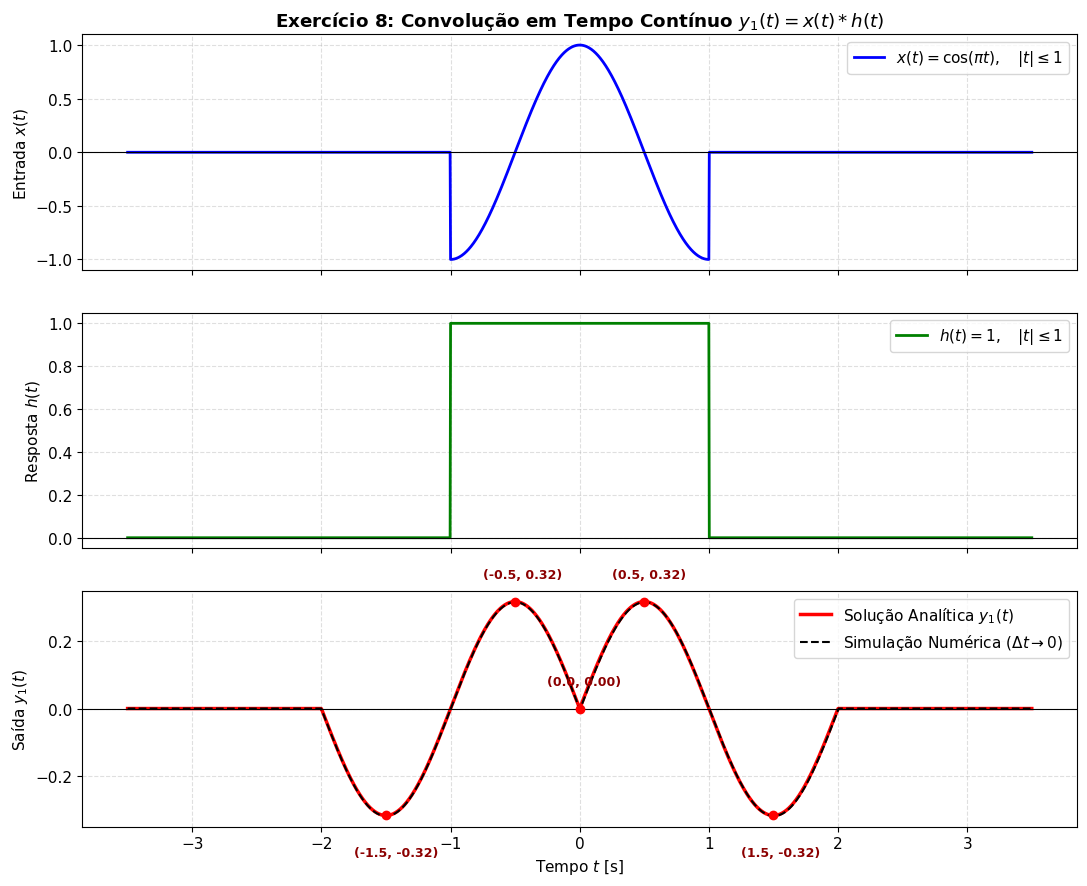

In [2]:
# Resolução Computacional do Exercício 8
import numpy as np
import matplotlib.pyplot as plt

t_cont = np.linspace(-3.5, 3.5, 2000)
dt = t_cont[1] - t_cont[0]

x_t = np.where(np.abs(t_cont) <= 1.0, np.cos(np.pi * t_cont), 0.0)
h_t = np.where(np.abs(t_cont) <= 1.0, 1.0, 0.0)

def y_analitica(t):
    y = np.zeros_like(t, dtype=float)
    idx1 = (t >= -2.0) & (t < 0.0)
    y[idx1] = -np.sin(np.pi * t[idx1]) / np.pi
    idx2 = (t >= 0.0) & (t <= 2.0)
    y[idx2] = np.sin(np.pi * t[idx2]) / np.pi
    return y

y_teorico = y_analitica(t_cont)
y_numerico = np.convolve(x_t, h_t, mode='same') * dt

fig, axs = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

axs[0].plot(t_cont, x_t, 'b-', lw=2, label=r'$x(t) = \cos(\pi t), \quad |t| \leq 1$')
axs[0].axhline(0, color='black', lw=0.8)
axs[0].set_ylabel('Entrada $x(t)$')
axs[0].set_title('Exercício 8: Convolução em Tempo Contínuo $y_1(t) = x(t) * h(t)$', fontweight='bold')
axs[0].legend(loc='upper right')

axs[1].plot(t_cont, h_t, 'g-', lw=2, label=r'$h(t) = 1, \quad |t| \leq 1$')
axs[1].axhline(0, color='black', lw=0.8)
axs[1].set_ylabel('Resposta $h(t)$')
axs[1].legend(loc='upper right')

axs[2].plot(t_cont, y_teorico, 'r-', lw=2.5, label='Solução Analítica $y_1(t)$')
axs[2].plot(t_cont, y_numerico, 'k--', lw=1.5, label=r'Simulação Numérica ($\Delta t \to 0$)')
axs[2].axhline(0, color='black', lw=0.8)
axs[2].set_xlabel('Tempo $t$ [s]')
axs[2].set_ylabel('Saída $y_1(t)$')

pontos_t = [-1.5, -0.5, 0.0, 0.5, 1.5]
for pt in pontos_t:
    val = y_analitica(np.array([pt]))[0]
    axs[2].plot(pt, val, 'ro')
    offset_y = 0.07 if val >= 0 else -0.12
    axs[2].annotate(f'({pt:.1f}, {val:.2f})', xy=(pt, val), xytext=(pt - 0.25, val + offset_y),
                    fontsize=9, weight='bold', color='darkred')

axs[2].legend(loc='upper right')
plt.tight_layout()
plt.show()


In [3]:
# Validação Simbólica com SymPy
import sympy as sp

t_sym, tau_sym = sp.symbols('t tau', real=True)
integrando = sp.cos(sp.pi * tau_sym) * 1

res_sympy_caso3 = sp.integrate(integrando, (tau_sym, t_sym - 1, 1))
res_sympy_caso2 = sp.integrate(integrando, (tau_sym, -1, t_sym + 1))

print("Validação Simbólica (SymPy):")
print(f"Para 0 <= t <= 2: y_1(t) = {sp.simplify(res_sympy_caso3)}")
print(f"Para -2 <= t < 0: y_1(t) = {sp.simplify(res_sympy_caso2)}")


Validação Simbólica (SymPy):
Para 0 <= t <= 2: y_1(t) = sin(pi*t)/pi
Para -2 <= t < 0: y_1(t) = sin(pi*(t + 1))/pi


---
## 3. Demonstração Interativa da Convolução Contínua (*Interactive Convolution Explorer*)

Compare agora com o módulo interativo de correlação: observe como o sinal $h(t - \tau)$ está **invertido** antes de ser deslocado (*Flip and Slide*).
Arraste o cursor do instante $t$ e acompanhe a formação da saída $y_1(t)$.


In [4]:
# Módulo Interativo de Convolução Contínua (Totalmente Autónomo)
import numpy as np
import matplotlib.pyplot as plt

def plot_convolucao_frame(t_val=-0.5):
    tau_grid = np.linspace(-4, 4, 1500)
    dtau = tau_grid[1] - tau_grid[0]
    
    # 1. Sinais x(tau) e h(t - tau)
    x_tau = np.where(np.abs(tau_grid) <= 1.0, np.cos(np.pi * tau_grid), 0.0)
    h_flipped_shifted = np.where(np.abs(t_val - tau_grid) <= 1.0, 1.0, 0.0)
    
    # Produto instantâneo
    prod = x_tau * h_flipped_shifted
    y_val = float(np.sum(prod) * dtau)
    
    # 2. Curva teórica completa
    t_full = np.linspace(-3.5, 3.5, 400)
    y_full = []
    for ti in t_full:
        if -2.0 <= ti < 0.0:
            y_full.append(-np.sin(np.pi * ti) / np.pi)
        elif 0.0 <= ti <= 2.0:
            y_full.append(np.sin(np.pi * ti) / np.pi)
        else:
            y_full.append(0.0)
    y_full = np.array(y_full)
    
    # 3. Construção do Gráfico
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7.5))
    
    # Domínio tau
    ax1.plot(tau_grid, x_tau, 'b-', lw=2.5, label=r'$x(\tau) = \cos(\pi \tau)$ (Fixo)')
    ax1.plot(tau_grid, h_flipped_shifted, 'g--', lw=2.0, label=f'$h({t_val:.2f} - \\tau)$ (Invertido e Deslocado)')
    ax1.fill_between(tau_grid, prod, color='gold', alpha=0.55, 
                     label=f'Área de Sobreposição (Integral = {y_val:.3f})')
    ax1.axvline(t_val, color='darkgreen', linestyle=':', label=f'Instante t = {t_val:.2f} s')
    ax1.axhline(0, color='black', lw=0.8)
    ax1.set_xlim(-3.5, 3.5)
    ax1.set_ylim(-1.3, 1.3)
    ax1.set_xlabel(r'Variável de Integração $\tau$ [s]')
    ax1.set_ylabel('Amplitude')
    ax1.set_title(f'Convolução Contínua: Mecanismo "Flip & Slide" para $t = {t_val:.2f}$ s', fontweight='bold')
    ax1.legend(loc='upper right', framealpha=0.9)
    
    # Domínio t (Saída acumulada)
    ax2.plot(t_full, y_full, 'r-', lw=2.5, label=r'Saída Analítica $y_1(t) = x(t) * h(t)$')
    
    t_past = t_full[t_full <= t_val]
    if len(t_past) > 0:
        y_past = y_full[:len(t_past)]
        ax2.plot(t_past, y_past, 'darkred', lw=3.5, label='Trajetória calculada')
        
    ax2.plot(t_val, y_val, 'ro', markersize=9, label=f'$y_1({t_val:.2f}) = {y_val:.3f}$')
    ax2.axvline(t_val, color='gray', linestyle=':')
    ax2.axhline(0, color='black', lw=0.8)
    ax2.set_xlim(-3.5, 3.5)
    ax2.set_ylim(-0.45, 0.45)
    ax2.set_xlabel('Tempo $t$ [s]')
    ax2.set_ylabel(r'$y_1(t)$')
    ax2.set_title('Sinal de Saída Resultante $y_1(t) = x(t) * h(t)$', fontweight='bold')
    ax2.legend(loc='upper right', framealpha=0.9)
    
    plt.tight_layout()
    plt.show()

# Inicialização com ipywidgets
try:
    from ipywidgets import interact, FloatSlider
    import ipywidgets as widgets
    slider = FloatSlider(min=-3.0, max=3.0, step=0.05, value=0.5, 
                         description='Instante t:', continuous_update=True,
                         layout=widgets.Layout(width='65%'))
    interact(plot_convolucao_frame, t_val=slider);
except ImportError:
    print("Módulo 'ipywidgets' não detetado. A renderizar visualização estática:")
    plot_convolucao_frame(t_val=0.5)


interactive(children=(FloatSlider(value=0.5, description='Instante t:', layout=Layout(width='65%'), max=3.0, m…

---
## 4. Exercício 11 — Convolução em Tempo Discreto

### Enunciado:
Considere os sinais discretos que representam a resposta impulsional $h[n]$ e a entrada $x[n]$ de um sistema LIT discreto:
$$h[n] = 1, \quad \text{para } 0 \le n \le 3 \quad (0 \text{ nos restantes instantes})$$
$$x[n] = \{2, 1\}, \quad \text{para } n \in \{0, 1\} \quad (0 \text{ nos restantes instantes})$$

Calcule analiticamente a saída $y[n] = x[n] * h[n]$ através de **quatro métodos complementares**, esboçando o resultado.

---

### Enquadramento Prévio: Suporte e Duração
- Suporte de $x[n]$: $n \in \{0, 1\} \implies n_{x,\text{mín}} = 0, \; n_{x,\text{máx}} = 1$ (Comprimento $L_x = 2$).
- Suporte de $h[n]$: $n \in \{0, 1, 2, 3\} \implies n_{h,\text{mín}} = 0, \; n_{h,\text{máx}} = 3$ (Comprimento $L_h = 4$).
- **Suporte da Saída $y[n]$:**
  $$n_{y,\text{mín}} = n_{x,\text{mín}} + n_{h,\text{mín}} = 0 + 0 = \mathbf{0}$$
  $$n_{y,\text{máx}} = n_{x,\text{máx}} + n_{h,\text{máx}} = 1 + 3 = \mathbf{4}$$
  Comprimento total: $L_y = L_x + L_h - 1 = 2 + 4 - 1 = \mathbf{5\text{ amostras}} \implies n \in \{0, 1, 2, 3, 4\}$.

---

### Resolução Analítica por 4 Métodos Complementares:

#### Método 1: Soma Direta da Convolução (*Flip & Slide* Amostra a Amostra)
Pela definição formal da convolução discreta:
$$y[n] = \sum_{k=-\infty}^{+\infty} x[k] h[n - k]$$
Como $x[k]$ só é não-nulo para $k=0$ ($x[0]=2$) e $k=1$ ($x[1]=1$), a soma reduz-se exatamente a dois termos para cada instante $n$:
$$y[n] = x[0] \cdot h[n] + x[1] \cdot h[n - 1] = 2h[n] + 1h[n - 1]$$

Calculando explicitamente para cada valor de $n$:
- **Para $n = 0$:** $y[0] = 2 \cdot h[0] + 1 \cdot h[-1] = 2(1) + 1(0) = \mathbf{2}$
- **Para $n = 1$:** $y[1] = 2 \cdot h[1] + 1 \cdot h[0] = 2(1) + 1(1) = 2 + 1 = \mathbf{3}$
- **Para $n = 2$:** $y[2] = 2 \cdot h[2] + 1 \cdot h[1] = 2(1) + 1(1) = 2 + 1 = \mathbf{3}$
- **Para $n = 3$:** $y[3] = 2 \cdot h[3] + 1 \cdot h[2] = 2(1) + 1(1) = 2 + 1 = \mathbf{3}$
- **Para $n = 4$:** $y[4] = 2 \cdot h[4] + 1 \cdot h[3] = 2(0) + 1(1) = 0 + 1 = \mathbf{1}$
- **Para $n < 0$ ou $n > 4$:** $y[n] = \mathbf{0}$

$$\mathbf{y[n] = \{2, 3, 3, 3, 1\}, \quad n \in \{0, 1, 2, 3, 4\}}$$

---

#### Método 2: Decomposição em Impulsos e Superposição LIT
1. Decomposição do sinal de entrada numa combinação linear de impulsos unitários de Kronecker $\delta[n]$:
   $$x[n] = 2\delta[n] + 1\delta[n - 1]$$
2. Pela **Linearidade e Invariância no Tempo** do sistema LIT ($\mathcal{T}\{\delta[n - k]\} = h[n - k]$):
   $$y[n] = \mathcal{T}\{x[n]\} = 2\mathcal{T}\{\delta[n]\} + 1\mathcal{T}\{\delta[n - 1]\} = 2h[n] + 1h[n - 1]$$
3. Superposição gráfica e numérica das respostas atrasadas:
   ```
   n:          0   1   2   3   4
   -----------------------------
   2 h[n]:     2   2   2   2   0
   1 h[n-1]:   0   1   1   1   1
   -----------------------------
   y[n]:       2   3   3   3   1
   ```

---

#### Método 3: Método Tabular e Anti-Diagonais de Produtos Cruzados
Construímos a tabela com a multiplicação elemento a elemento $x[k] \times h[m]$, onde o instante de saída resultante é dado pela soma dos índices $n = k + m$.
Os termos somam-se ao longo das **anti-diagonais** (linhas inclinadas $k + m = n$):

| $x[k] \backslash h[m]$ | $h[0] = 1$ | $h[1] = 1$ | $h[2] = 1$ | $h[3] = 1$ |
| :---: | :---: | :---: | :---: | :---: |
| **$x[0] = 2$** ($k=0$) | **2** ($n=0$) | **2** ($n=1$) | **2** ($n=2$) | **2** ($n=3$) |
| **$x[1] = 1$** ($k=1$) | **1** ($n=1$) | **1** ($n=2$) | **1** ($n=3$) | **1** ($n=4$) |

Somando os elementos de cada anti-diagonal $n = k + m$:
- $n = 0$: $2 = \mathbf{2}$
- $n = 1$: $2 + 1 = \mathbf{3}$
- $n = 2$: $2 + 1 = \mathbf{3}$
- $n = 3$: $2 + 1 = \mathbf{3}$
- $n = 4$: $1 = \mathbf{1}$

---

#### Método 4: Formulação Matricial com Matriz de Convolução (Matriz de Toeplitz)

> **O que é uma Matriz de Toeplitz?**  
> Uma **Matriz de Toeplitz** (ou matriz diagonal-constante) é uma matriz em que **todos os elementos ao longo de cada diagonal descendente (da esquerda para a direita) são idênticos/constantes**, ou seja:
> $$A_{i, j} = A_{i+1, \, j+1} = a_{i - j}$$
>
> Na convolução linear entre sinais de suporte finito, a operação $y[n] = x[n] * h[n]$ pode ser escrita na forma matricial $\mathbf{y} = \mathbf{H} \mathbf{x}$, onde $\mathbf{H}$ é uma matriz de Toeplitz de dimensão $L_y \times L_x$ ($5 \times 2$ no nosso caso).  
> A primeira coluna contém a resposta impulsional $h[n]$ preenchida com zeros até ao comprimento $L_y$, e cada coluna subsequente é obtida deslocando a coluna anterior uma posição para baixo (representando o atraso temporal de uma amostra):
> $$\mathbf{H} = \begin{bmatrix} 
> h[0] & 0 \\ 
> h[1] & h[0] \\ 
> h[2] & h[1] \\ 
> h[3] & h[2] \\ 
> 0    & h[3] 
> \end{bmatrix}$$

Aplicando com os valores numéricos do exercício ($h = [1, 1, 1, 1]^T$ e $x = [2, 1]^T$):
$$\begin{bmatrix} y[0] \\ y[1] \\ y[2] \\ y[3] \\ y[4] \end{bmatrix} = \begin{bmatrix} 
1 & 0 \\ 
1 & 1 \\ 
1 & 1 \\ 
1 & 1 \\ 
0 & 1 
\end{bmatrix} \begin{bmatrix} 2 \\ 1 \end{bmatrix} = \begin{bmatrix} 1(2) + 0(1) \\ 1(2) + 1(1) \\ 1(2) + 1(1) \\ 1(2) + 1(1) \\ 0(2) + 1(1) \end{bmatrix} = \mathbf{\begin{bmatrix} 2 \\ 3 \\ 3 \\ 3 \\ 1 \end{bmatrix}}$$

Note-se a estrutura de Toeplitz: a diagonal principal tem apenas $1$'s, a subdiagonal tem apenas $1$'s, e a superdiagonal tem apenas $0$'s!


Resultados Numéricos da Convolução Discreta:
Instantes n: [0 1 2 3 4]
Valores de y[n]: [2 3 3 3 1]


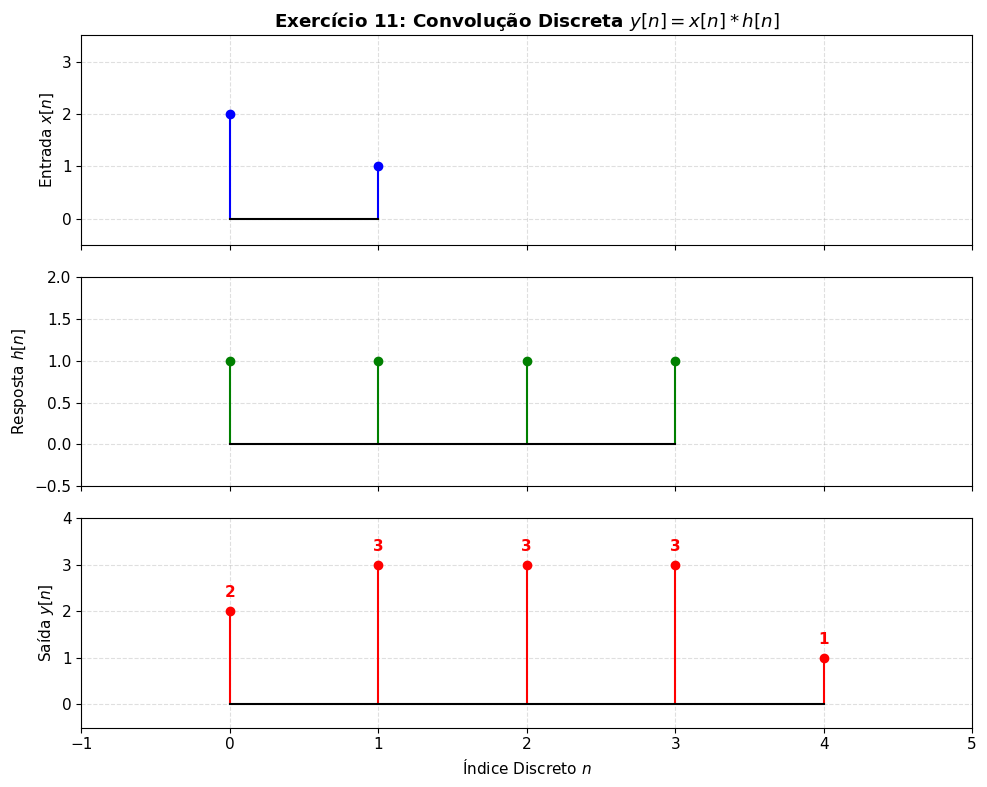

In [5]:
# Resolução Computacional do Exercício 11
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

n_x = np.array([0, 1])
x = np.array([2, 1])

n_h = np.array([0, 1, 2, 3])
h = np.array([1, 1, 1, 1])

# Convolução discreta via scipy / numpy
y = np.convolve(x, h)
n_y = np.arange(n_x[0] + n_h[0], n_x[-1] + n_h[-1] + 1)

print("Resultados Numéricos da Convolução Discreta:")
print(f"Instantes n: {n_y}")
print(f"Valores de y[n]: {y}")

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axs[0].stem(n_x, x, linefmt='b-', markerfmt='bo', basefmt='k-')
axs[0].set_title('Exercício 11: Convolução Discreta $y[n] = x[n] * h[n]$', fontweight='bold')
axs[0].set_ylabel('Entrada $x[n]$')
axs[0].set_ylim(-0.5, 3.5)

axs[1].stem(n_h, h, linefmt='g-', markerfmt='go', basefmt='k-')
axs[1].set_ylabel('Resposta $h[n]$')
axs[1].set_ylim(-0.5, 2.0)

axs[2].stem(n_y, y, linefmt='r-', markerfmt='ro', basefmt='k-')
axs[2].set_xlabel('Índice Discreto $n$')
axs[2].set_ylabel('Saída $y[n]$')
axs[2].set_ylim(-0.5, 4.0)
axs[2].set_xticks(np.arange(-1, 6))

for i, txt in enumerate(y):
    axs[2].annotate(f'{txt}', (n_y[i], txt + 0.3), ha='center', fontweight='bold', color='red')

plt.tight_layout()
plt.show()


In [ ]:
# Visualização Interativa da Convolução Discreta
import numpy as np
import matplotlib.pyplot as plt

def plot_convolucao_discreta_frame(n_deslocamento=2):
    k_range = np.arange(-2, 6)
    x_k = np.array([2 if k==0 else 1 if k==1 else 0 for k in k_range])
    h_n_minus_k = np.array([1 if 0 <= (n_deslocamento - k) <= 3 else 0 for k in k_range])
    
    prod_k = x_k * h_n_minus_k
    y_actual = int(np.sum(prod_k))
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6.5))
    
    ax1.stem(k_range - 0.1, x_k, linefmt='b-', markerfmt='bo', basefmt='k-', label=r'$x[k]$')
    ax1.stem(k_range + 0.1, h_n_minus_k, linefmt='g--', markerfmt='gs', basefmt='k-', label=f'h[{n_deslocamento} - k]')
    ax1.bar(k_range, prod_k, color='gold', alpha=0.5, width=0.4, label=f'Produto x[k]h[{n_deslocamento}-k] (Soma = {y_actual})')
    ax1.set_title(f'Multiplicação e Acumulação no domínio $k$ para $n = {n_deslocamento}$', fontweight='bold')
    ax1.set_xlabel('Índice $k$')
    ax1.set_ylabel('Amplitude')
    ax1.set_ylim(-0.5, 3.2)
    ax1.legend(loc='upper right')
    
    # Saída completa
    n_all = np.arange(0, 5)
    y_all = [2, 3, 3, 3, 1]
    ax2.stem(n_all, y_all, linefmt='gray', markerfmt='o', basefmt='k-', label='Saída completa $y[n]$')
    if 0 <= n_deslocamento <= 4:
        ax2.stem([n_deslocamento], [y_actual], linefmt='r-', markerfmt='ro', basefmt='k-', label=f'y[{n_deslocamento}] = {y_actual}')
    ax2.set_xlabel('Índice $n$')
    ax2.set_ylabel('Saída $y[n]$')
    ax2.set_xlim(-2, 6)
    ax2.set_ylim(-0.5, 4.0)
    ax2.set_title('Sequência de Saída $y[n] = x[n] * h[n]$', fontweight='bold')
    ax2.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

try:
    from ipywidgets import interact, IntSlider
    import ipywidgets as widgets
    slider_disc = IntSlider(min=-1, max=5, step=1, value=2, 
                            description='Amostra n:', continuous_update=True,
                            layout=widgets.Layout(width='65%'))
    interact(plot_convolucao_discreta_frame, n_deslocamento=slider_disc);
except ImportError:
    print("Módulo 'ipywidgets' não detetado. A renderizar visualização estática:")
    plot_convolucao_discreta_frame(n_deslocamento=2)


---
## 5. Exercício 14 — Resposta ao Degrau Unitário ($s(t)$ e $s[n]$)

### Enunciado:
Calcule e esboce a resposta ao degrau unitário para os sistemas LIT com as seguintes respostas impulsionais:
- **a) Tempo Contínuo:** $h(t) = e^{-|t|}$
- **d) Tempo Discreto:** $h[n] = \delta[n] - \delta[n-2]$

---

### Resolução Analítica:

#### Alínea 14a — Tempo Contínuo: $h(t) = e^{-|t|}$
A resposta ao degrau é dada pela integração de $h(\tau)$ desde $-\infty$ até $t$:
$$s(t) = \int_{-\infty}^{t} h(\tau) d\tau = \int_{-\infty}^{t} e^{-|\tau|} d\tau$$

Como $|\tau| = -\tau$ para $\tau < 0$ e $|\tau| = \tau$ para $\tau \ge 0$, dividimos em dois casos:
1. **Para $t < 0$:**
   $$s(t) = \int_{-\infty}^{t} e^{\tau} d\tau = \left[ e^{\tau} \right]_{-\infty}^{t} = \mathbf{e^t}$$
2. **Para $t \ge 0$:**
   $$s(t) = \int_{-\infty}^{0} e^{\tau} d\tau + \int_{0}^{t} e^{-\tau} d\tau = 1 + \left[ -e^{-\tau} \right]_{0}^{t} = 1 + (-e^{-t} - (-1)) = \mathbf{2 - e^{-t}}$$

**Expressão Final:**
$$\mathbf{s(t) = \begin{cases} e^t, & t < 0 \\[4pt] 2 - e^{-t}, & t \ge 0 \end{cases} = e^t u(-t) + (2 - e^{-t}) u(t)}$$

---

#### Alínea 14d — Tempo Discreto: $h[n] = \delta[n] - \delta[n-2]$
A resposta ao degrau unitário no domínio discreto é a acumulação da resposta impulsional:
$$s[n] = \sum_{k=-\infty}^{n} h[k] = \sum_{k=-\infty}^{n} (\delta[k] - \delta[k-2])$$

Lembrando que $\sum_{k=-\infty}^{n} \delta[k - k_0] = u[n - k_0]$:
$$s[n] = u[n] - u[n-2] = \mathbf{\delta[n] + \delta[n-1]} = \begin{cases} 1, & n \in \{0, 1\} \\[4pt] 0, & \text{caso contrário} \end{cases}$$


In [ ]:
# Simulação do Exercício 14a
import numpy as np
import matplotlib.pyplot as plt

t_ex14 = np.linspace(-4, 4, 1000)
h_ex14 = np.exp(-np.abs(t_ex14))
s_analitica = np.where(t_ex14 < 0, np.exp(t_ex14), 2.0 - np.exp(-t_ex14))

dt_14 = t_ex14[1] - t_ex14[0]
s_numerica = np.cumsum(h_ex14) * dt_14

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax1.plot(t_ex14, h_ex14, 'b-', lw=2, label=r'$h(t) = e^{-|t|}$')
ax1.fill_between(t_ex14, h_ex14, color='lightblue', alpha=0.3)
ax1.axhline(0, color='black', lw=0.8)
ax1.set_ylabel(r'$h(t)$')
ax1.set_title('Exercício 14a: Resposta Impulsional $h(t) = e^{-|t|}$ (Sistema Não Causal)', fontweight='bold')
ax1.legend(loc='upper right')

ax2.plot(t_ex14, s_analitica, 'r-', lw=2.5, label=r'Solução Analítica $s(t) = e^t u(-t) + (2 - e^{-t})u(t)$')
ax2.plot(t_ex14, s_numerica, 'k--', lw=1.2, label='Integração Numérica')
ax2.axhline(1.0, color='gray', linestyle=':', label='Transição em $t=0$ ($s(0)=1$)')
ax2.axhline(2.0, color='darkgreen', linestyle='--', label=r'Assíntota $s(\infty)=2$')
ax2.axhline(0, color='black', lw=0.8)
ax2.plot(0, 1.0, 'ro', markersize=7)
ax2.set_xlabel('Tempo $t$ [s]')
ax2.set_ylabel(r'Resposta ao Degrau $s(t)$')
ax2.set_title('Resposta ao Degrau Unitário $s(t)$', fontweight='bold')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()


In [ ]:
# Simulação do Exercício 14d
import numpy as np
import matplotlib.pyplot as plt

n_ex14d = np.arange(-3, 6)
h_14d = np.array([1 if n==0 else -1 if n==2 else 0 for n in n_ex14d])
s_14d = np.array([1 if n in [0, 1] else 0 for n in n_ex14d])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)

ax1.stem(n_ex14d, h_14d, linefmt='g-', markerfmt='go', basefmt='k-')
ax1.set_ylabel(r'$h[n]$')
ax1.set_title('Exercício 14d: Resposta Impulsional $h[n] = \delta[n] - \delta[n-2]$', fontweight='bold')
ax1.set_ylim(-1.5, 1.5)

ax2.stem(n_ex14d, s_14d, linefmt='r-', markerfmt='ro', basefmt='k-')
ax2.set_xlabel('Índice Discreto $n$')
ax2.set_ylabel(r'$s[n]$')
ax2.set_title(r'Resposta ao Degrau $s[n] = u[n] - u[n-2] = \delta[n] + \delta[n-1]$', fontweight='bold')
ax2.set_ylim(-0.5, 1.8)
ax2.set_xticks(n_ex14d)

for n, val in zip(n_ex14d, s_14d):
    ax2.annotate(f'{val}', (n, val + 0.15), ha='center', fontweight='bold', color='red')

plt.tight_layout()
plt.show()


---
## 6. Síntese e Conclusões da Parte 2

| Operação / Conceito | Domínio Contínuo | Domínio Discreto | Significado Físico / Aplicação |
| :--- | :--- | :--- | :--- |
| **Convolução** | $y(t) = \int_{-\infty}^{\infty} x(\tau) h(t-\tau) d\tau$ | $y[n] = \sum x[k] h[n-k]$ | Saída de sistemas LIT (*Flip & Slide*). |
| **Resposta ao Degrau** | $s(t) = \int_{-\infty}^t h(\tau) d\tau$ | $s[n] = \sum_{k=-\infty}^n h[k]$ | Comportamento transitório e ganho estático. |
| **Diferenciação / Diferenças** | $h(t) = \frac{ds(t)}{dt}$ | $h[n] = s[n] - s[n-1]$ | Obtenção de $h$ a partir da resposta ao degrau $s$. |
